# Excercise: Wolff Algorithm
1. Repeat the simulation as the previous assignment but using Wolff cluster algorithm.
2. Tasks: Plot the magnetization and energy as the function of $\beta$.
3. Compare Metropolis and Wolff cluster algorithm.

## Imports

In [1]:
from collections import deque

from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## Grid init

In [2]:
N = 20
grid_cold = np.ones((N, N))*-1
grid_random = np.random.choice(a=[-1,1], size=(N,N), replace=True)
grid_hot = np.ones((N,N))
print(grid_random)

[[ 1  1  1  1  1 -1  1 -1  1 -1  1 -1  1 -1  1 -1  1 -1  1  1]
 [-1 -1  1  1  1  1 -1 -1  1  1 -1  1  1  1 -1 -1  1 -1  1 -1]
 [-1  1  1  1  1 -1  1  1  1 -1 -1 -1 -1 -1  1 -1 -1 -1  1  1]
 [ 1 -1  1  1 -1 -1  1  1  1 -1  1  1 -1 -1  1 -1 -1  1  1  1]
 [ 1 -1  1  1  1  1  1 -1  1  1  1 -1  1 -1 -1  1 -1 -1  1  1]
 [-1  1  1  1  1  1  1  1 -1 -1  1 -1 -1  1  1  1  1 -1 -1  1]
 [ 1  1  1 -1 -1  1  1  1  1  1  1  1 -1 -1 -1  1  1  1  1 -1]
 [-1  1  1 -1  1  1 -1  1  1  1  1 -1 -1 -1 -1  1  1 -1  1  1]
 [ 1 -1  1  1  1 -1 -1  1 -1 -1  1 -1 -1  1  1  1  1 -1 -1 -1]
 [ 1 -1  1  1  1 -1 -1  1 -1 -1 -1 -1 -1  1 -1  1 -1  1  1 -1]
 [ 1  1  1 -1 -1 -1 -1  1 -1 -1  1  1 -1 -1  1  1 -1 -1 -1  1]
 [-1  1  1  1  1  1  1 -1 -1  1 -1 -1  1  1 -1  1  1  1 -1  1]
 [ 1 -1  1  1  1 -1 -1  1 -1  1 -1  1  1  1  1 -1  1 -1 -1  1]
 [ 1 -1  1  1 -1  1 -1 -1 -1  1 -1  1  1 -1  1 -1 -1  1  1  1]
 [ 1  1  1  1  1 -1 -1 -1  1 -1 -1  1 -1  1 -1  1 -1 -1  1  1]
 [-1  1 -1 -1  1 -1 -1 -1 -1 -1  1  1  1 -1 -1 -1  1 -1

## Help funcs

In [3]:
def get_total_energy_system(grid, J=1.0, B=0.0):
    right_neighbours = np.roll(grid, 1, axis=1)
    down_neighbours = np.roll(grid, 1, axis=0)

    spin_sum = -1 * J * np.sum(grid * (right_neighbours + down_neighbours))

    if B != 0.0:
        field_sum = -1*B*np.sum(grid)
    else:
        field_sum = 0.0

    return spin_sum + field_sum

In [4]:
def visualize_grid(grid):
    cmap = plt.cm.coolwarm

    sns.heatmap(
        grid,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        cbar=False,
    )

    plt.show()

In [5]:
def plot_stats(mag,tot_en, sus, title_model):
    mag_arr = np.array(mag)
    en_arr = np.array(tot_en)
    sus_arr = np.array(sus)
    betas = np.arange(0, 1, 0.05)
    labels = ['Start: Hot (all 1)', 'Start: Cold (all -1)', 'Start: Random']
    colors = ['#d62728', '#1f77b4', '#2ca02c']
    critical_beta = 0.4407

    fig, axs = plt.subplots(3, 3, figsize=(18, 14), sharex=True)

    for i in range(3):
        # --- Row 1: Magnetization ---
        axs[0, i].plot(betas, mag_arr[:, i], 'o-', color=colors[i], markersize=4)
        axs[0, i].set_title(f"Magnetization ({labels[i]})", fontweight='bold')
        axs[0, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
        axs[0, i].grid(True, linestyle=':', alpha=0.6)
        if i == 0: axs[0, i].set_ylabel(r"$\langle |M| \rangle$")

        # --- Row 2: Total Energy ---
        axs[1, i].plot(betas, en_arr[:, i], 's-', color=colors[i], markersize=4)
        axs[1, i].set_title(f"Total Energy ({labels[i]})", fontweight='bold')
        axs[1, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
        axs[1, i].grid(True, linestyle=':', alpha=0.6)
        if i == 0: axs[1, i].set_ylabel("Energy (E)")

        # --- Row 3: Susceptibility ---
        axs[2, i].plot(betas, sus_arr[:, i], '^-', color=colors[i], markersize=4)
        axs[2, i].set_title(f"Susceptibility ({labels[i]})", fontweight='bold')
        axs[2, i].set_xlabel(r"Inverse Temperature $\beta$")
        axs[2, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
        axs[2, i].grid(True, linestyle=':', alpha=0.6)
        if i == 0: axs[2, i].set_ylabel(r"Susceptibility $\chi$")

    axs[0, 0].plot([], [], color='orange', linestyle='--', label='Critical Beta (~0.44)')
    fig.legend(loc='upper center', ncol=1, frameon=False)

    plt.suptitle(f"2D Ising Model({title_model}): Statistical Properties vs. Inverse Temperature", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Algorithms

In [6]:
def wolff_step(grid, beta, J=1.0):
    N = len(grid)
    random_index = np.random.randint(N * N)
    x_seed = random_index // N
    y_seed = random_index % N

    seed_spin = grid[x_seed, y_seed]
    cluster = {(x_seed, y_seed)}
    queue = deque([(x_seed, y_seed)])


    # accept prob
    acc_prob = 1.0 - np.exp(-2*beta*J)

    # neighbours checks
    while len(queue) > 0:
        x, y = queue.popleft()

        neighbours = (
            ((x-1)%N,y),
            ((x+1)%N,y),
            (x,(y-1)%N),
            (x,(y+1)%N)
        )

        # check neighbours
        for x_n, y_n in neighbours:
            # if in cluster or opposite spin -> we skip
            if ((x_n,y_n) not in cluster) and (grid[x_n,y_n] == seed_spin):
                if np.random.random() < acc_prob:
                    queue.append((x_n,y_n))
                    cluster.add((x_n,y_n))

    # cluster switching the spin
    for x, y in cluster:
        grid[x, y] *= -1

    return grid

In [7]:
def monte_carlo_metropolis_step(grid, beta):
    def __boltzmann_probability(delta_e, beta):
        return np.exp(-beta * delta_e)

    def __local_spin_energy_change(grid, i, j, J=1, B=0):
        '''
        function switch the spin at specific index and checks how it would effect the total energy. Does not affect the grid

        :param grid: old grid
        :param i: x index in grid
        :param j: y index in grid
        :param J: interaction strength
        :param B: external field
        :return: value of local spin energy change
        '''
        N = len(grid)
        old_spin = grid[i, j]
        neighbours = (
            grid[(i-1)%N,j] +
            grid[(i+1)%N,j] +
            grid[i,(j-1)%N] +
            grid[i,(j+1)%N]
        )

        return 2 * old_spin  * (J * neighbours  + B)

    N = len(grid)

    for _ in range(N * N):
        random_index = np.random.randint(N * N)
        x_ind = random_index // N
        y_ind = random_index % N

        delta_e = __local_spin_energy_change(grid, x_ind, y_ind)

        # Logika Metropolis
        if delta_e <= 0:
            grid[x_ind, y_ind] *= -1
        else:
            if np.random.random() <= __boltzmann_probability(delta_e, beta):
                grid[x_ind, y_ind] *= -1

    return grid

## Simulators

In [8]:
def ising_simulation_with_stats(grid, step_func, beta, steps, burn_in_steps=0, verbose=False):
    active_steps = steps - burn_in_steps
    if active_steps <= 0:
        print("[WARNING] burn_in_steps is more or equal than the number of steps")
        return grid, 0, 0, 0

    _grid = deepcopy(grid)
    _sum_mag = 0.0
    _sum_mag_sq = 0.0
    _sum_en = 0.0  # Dodana zmienna do sumowania energii
    N_sq = len(grid)**2

    bar = range(steps)

    for i in bar:
        _grid = step_func(_grid, beta)

        if i >= burn_in_steps:
            # Obliczanie magnetyzacji
            current_m = np.abs(np.sum(_grid)) / N_sq
            _sum_mag += current_m
            _sum_mag_sq += current_m**2

            # Obliczanie energii i dodawanie do sumy (UŚREDNIANIE)
            current_e = get_total_energy_system(_grid, J=1, B=0.0)
            _sum_en += current_e

    # Statystyki końcowe
    _avg_mag = _sum_mag / active_steps
    _avg_mag_sq = _sum_mag_sq / active_steps
    _total_en = _sum_en / active_steps  # Średnia energia zamiast ostatniej wartości

    # Podatność magnetyczna: chi = beta * N^2 * (<m^2> - <m>^2)
    _susceptibility = beta * N_sq * (_avg_mag_sq - (_avg_mag**2))

    if verbose:
        print("Total magnetism (avg): ", _avg_mag,
              "Total energy (avg): ", _total_en,
              "Total susceptibility: ", _susceptibility, sep='\n')

    return _grid, _avg_mag, _total_en, _susceptibility

In [9]:
print("-="*5, "MCMC", "-="*5)
print("="*6, "Hot Grid", "="*6)
mcmc_grid_hot, _, _, _ = ising_simulation_with_stats(grid=grid_hot, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)
print("="*6, "Cold Grid", "="*6)
mcmc_grid_cold, _, _, _ = ising_simulation_with_stats(grid=grid_cold, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)
print("="*6, "Random Grid", "="*6)
mcmc_grid_rand, _, _, _ = ising_simulation_with_stats(grid=grid_random, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)

-=-=-=-=-= MCMC -=-=-=-=-=
====== Hot Grid ======
Total magnetism (avg): 
0.973918749999974
Total energy (avg): 
-764.1133333333333
Total susceptibility: 
0.05781691563785607
====== Cold Grid ======
Total magnetism (avg): 
0.9739052083333035
Total energy (avg): 
-763.8341666666666
Total susceptibility: 
0.054948593505779186
====== Random Grid ======
Total magnetism (avg): 
0.9740260416666403
Total energy (avg): 
-764.2933333333333
Total susceptibility: 
0.058913587253828226


In [10]:
print("-="*5, "Wolff", "-="*5)
print("="*6, "Hot Grid", "="*6)
wolff_grid_hot, _, _, _ = ising_simulation_with_stats(grid=grid_hot, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)
print("="*6, "Cold Grid", "="*6)
wolff_grid_cold, _, _, _ = ising_simulation_with_stats(grid=grid_cold, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)
print("="*6, "Random Grid", "="*6)
wolff_grid_rand, _, _, _ = ising_simulation_with_stats(grid=grid_random, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200, verbose=True)

-=-=-=-=-= Wolff -=-=-=-=-=
====== Hot Grid ======
Total magnetism (avg): 
0.9727229166666415
Total energy (avg): 
-762.68
Total susceptibility: 
0.05822057397200098
====== Cold Grid ======
Total magnetism (avg): 
0.9733395833333067
Total energy (avg): 
-763.2833333333333
Total susceptibility: 
0.06035082397221281
====== Random Grid ======
Total magnetism (avg): 
0.9734510416666401
Total energy (avg): 
-763.305
Total susceptibility: 
0.0539329247523046


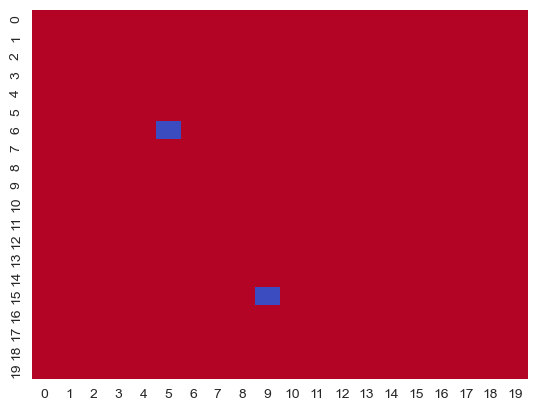

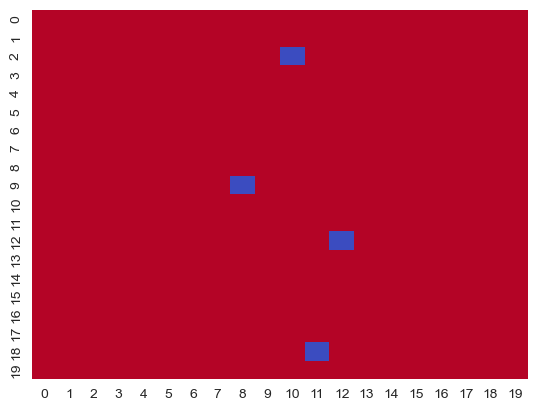

In [11]:
visualize_grid(mcmc_grid_hot)
visualize_grid(wolff_grid_hot)

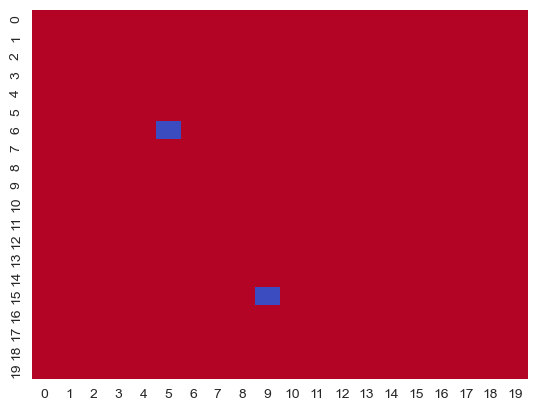

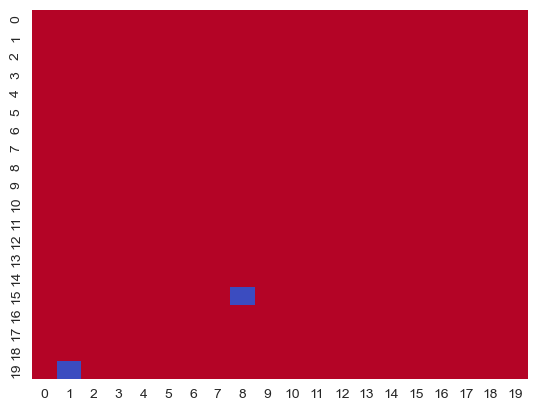

In [12]:
visualize_grid(mcmc_grid_hot)
visualize_grid(wolff_grid_rand)

## Beta plots

In [13]:
# Listy na wyniki dla Metropolisa
mag_metropolis = []
tot_en_metropolis = []
sus_metropolis = []

# Parametry - trzymamy takie same jak w poprzednim zadaniu
steps_metropolis = 2000
burn_in_metropolis = 500
betas = np.arange(0, 1, 0.05)

bar = tqdm(betas)

for beta in bar:
    bar.set_description(f"Metropolis Beta: {beta:.2f}")

    g_hot = deepcopy(grid_hot)
    g_cold = deepcopy(grid_cold)
    g_rand = deepcopy(grid_random)

    _, hot_m, hot_e, hot_s = ising_simulation_with_stats(grid=g_hot, step_func=monte_carlo_metropolis_step, beta=beta, steps=steps_metropolis, burn_in_steps=burn_in_metropolis)
    _, cold_m, cold_e, cold_s = ising_simulation_with_stats(grid=g_cold, step_func=monte_carlo_metropolis_step, beta=beta, steps=steps_metropolis, burn_in_steps=burn_in_metropolis)
    _, rand_m, rand_e, rand_s = ising_simulation_with_stats(grid=g_rand, step_func=monte_carlo_metropolis_step, beta=beta, steps=steps_metropolis, burn_in_steps=burn_in_metropolis)

    mag_metropolis.append([hot_m, cold_m, rand_m])
    tot_en_metropolis.append([hot_e, cold_e, rand_e])
    sus_metropolis.append([hot_s, cold_s, rand_s])

mag_metropolis = np.array(mag_metropolis)
tot_en_metropolis = np.array(tot_en_metropolis)
sus_metropolis = np.array(sus_metropolis)

Metropolis Beta: 0.95: 100%|██████████| 20/20 [02:20<00:00,  7.02s/it]


In [14]:
# Listy na wyniki dla Wolffa
mag_wolff = []
tot_en_wolff = []
sus_wolff = []

steps_wolff = 3000
burn_in_wolff = 500
betas = np.arange(0, 1, 0.05)

bar = tqdm(betas)

for beta in bar:
    bar.set_description(f"Wolff Beta: {beta:.2f}")

    g_hot = deepcopy(grid_hot)
    g_cold = deepcopy(grid_cold)
    g_rand = deepcopy(grid_random)

    _, hot_m, hot_e, hot_s = ising_simulation_with_stats(grid=g_hot, step_func=wolff_step, beta=beta, steps=steps_wolff, burn_in_steps=burn_in_wolff)
    _, cold_m, cold_e, cold_s = ising_simulation_with_stats(grid=g_cold, step_func=wolff_step, beta=beta, steps=steps_wolff, burn_in_steps=burn_in_wolff)
    _, rand_m, rand_e, rand_s = ising_simulation_with_stats(grid=g_rand, step_func=wolff_step, beta=beta, steps=steps_wolff, burn_in_steps=burn_in_wolff)

    mag_wolff.append([hot_m, cold_m, rand_m])
    tot_en_wolff.append( [hot_e, cold_e, rand_e])
    sus_wolff.append([hot_s, cold_s, rand_s])

mag_wolff = np.array(mag_wolff)
tot_en_wolff = np.array(tot_en_wolff)
sus_wolff = np.array(sus_wolff)

Wolff Beta: 0.95: 100%|██████████| 20/20 [00:43<00:00,  2.20s/it]


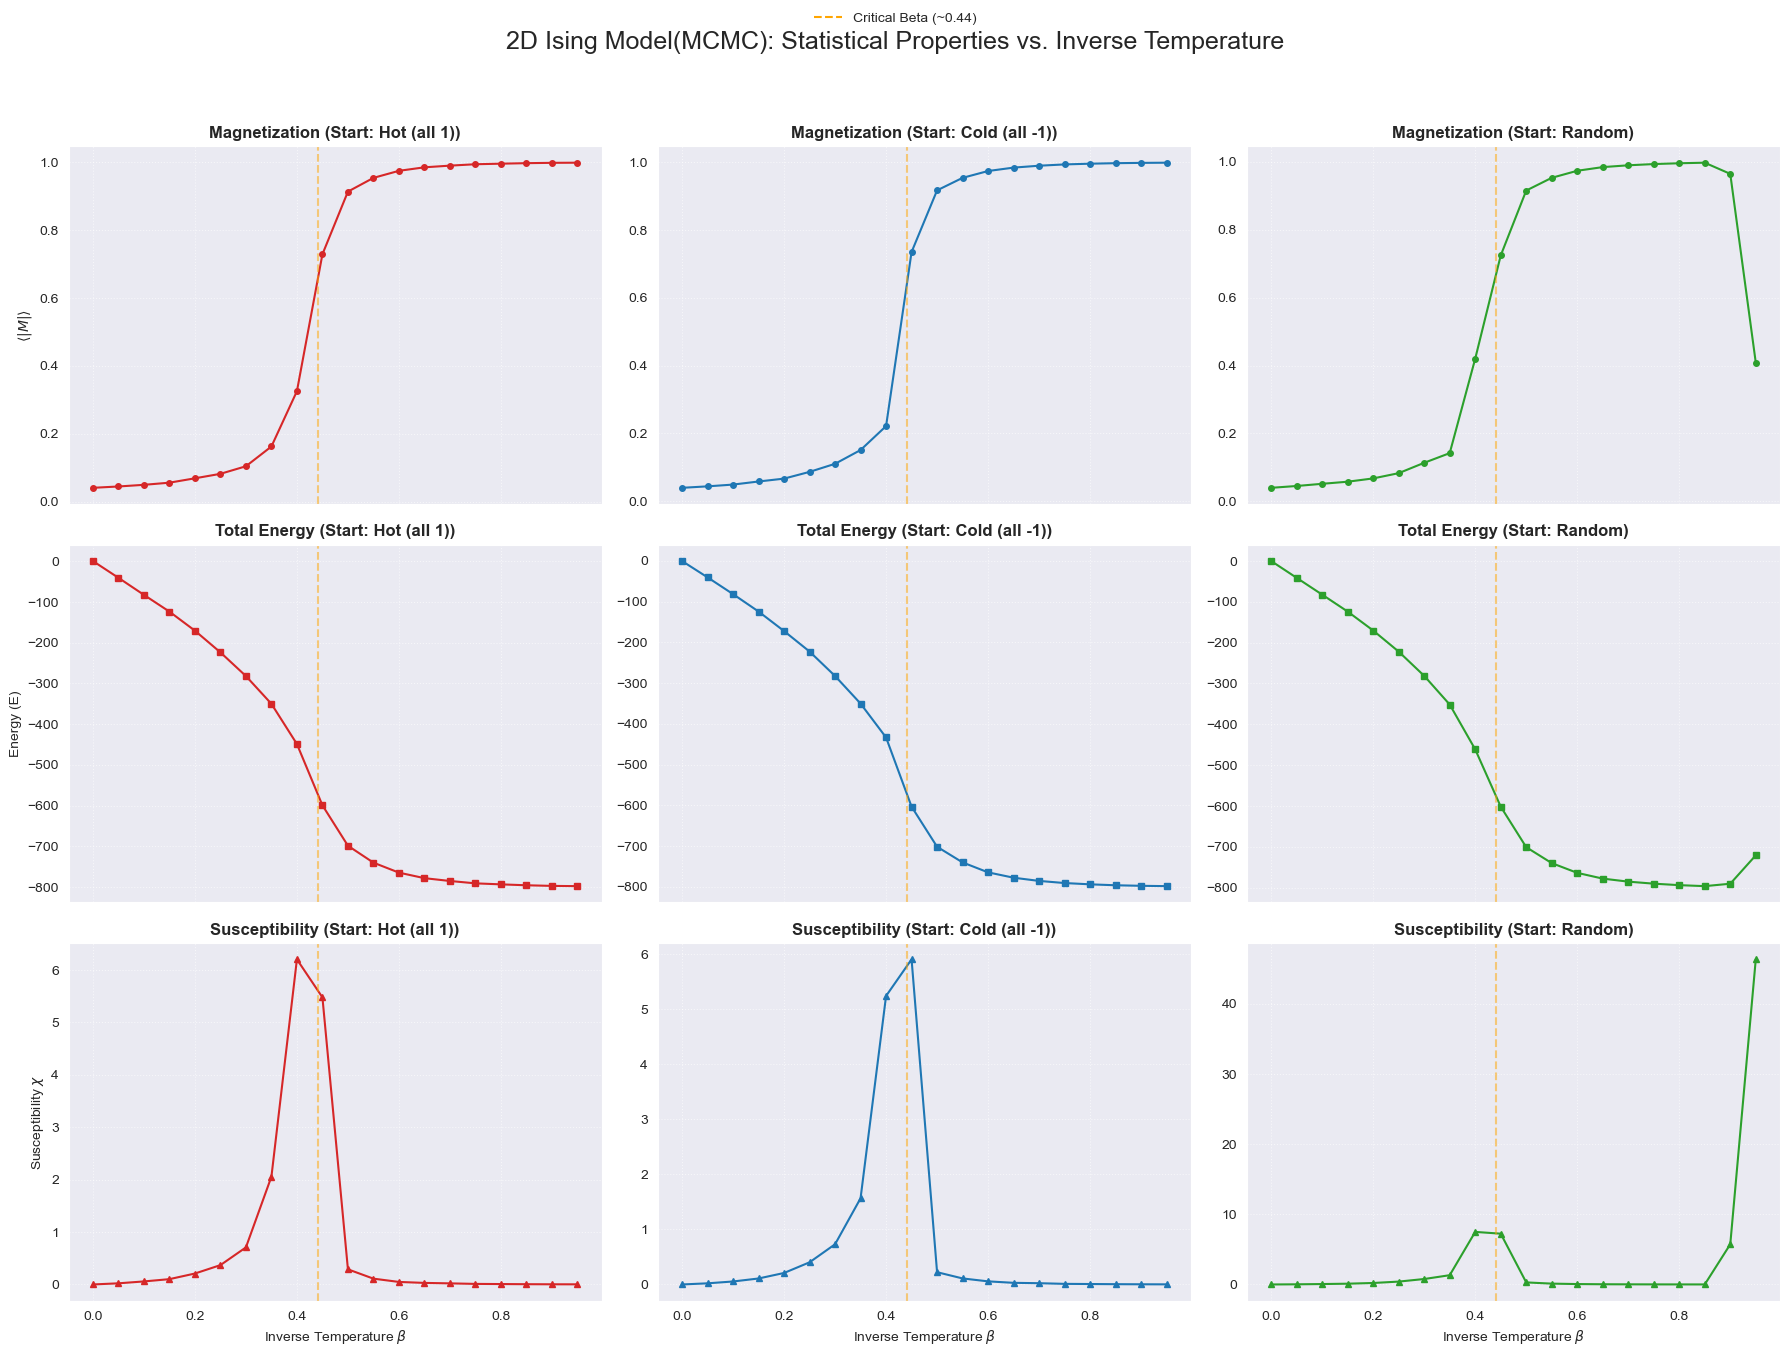

In [15]:
plot_stats(mag = mag_metropolis, tot_en = tot_en_metropolis, sus = sus_metropolis, title_model="MCMC")

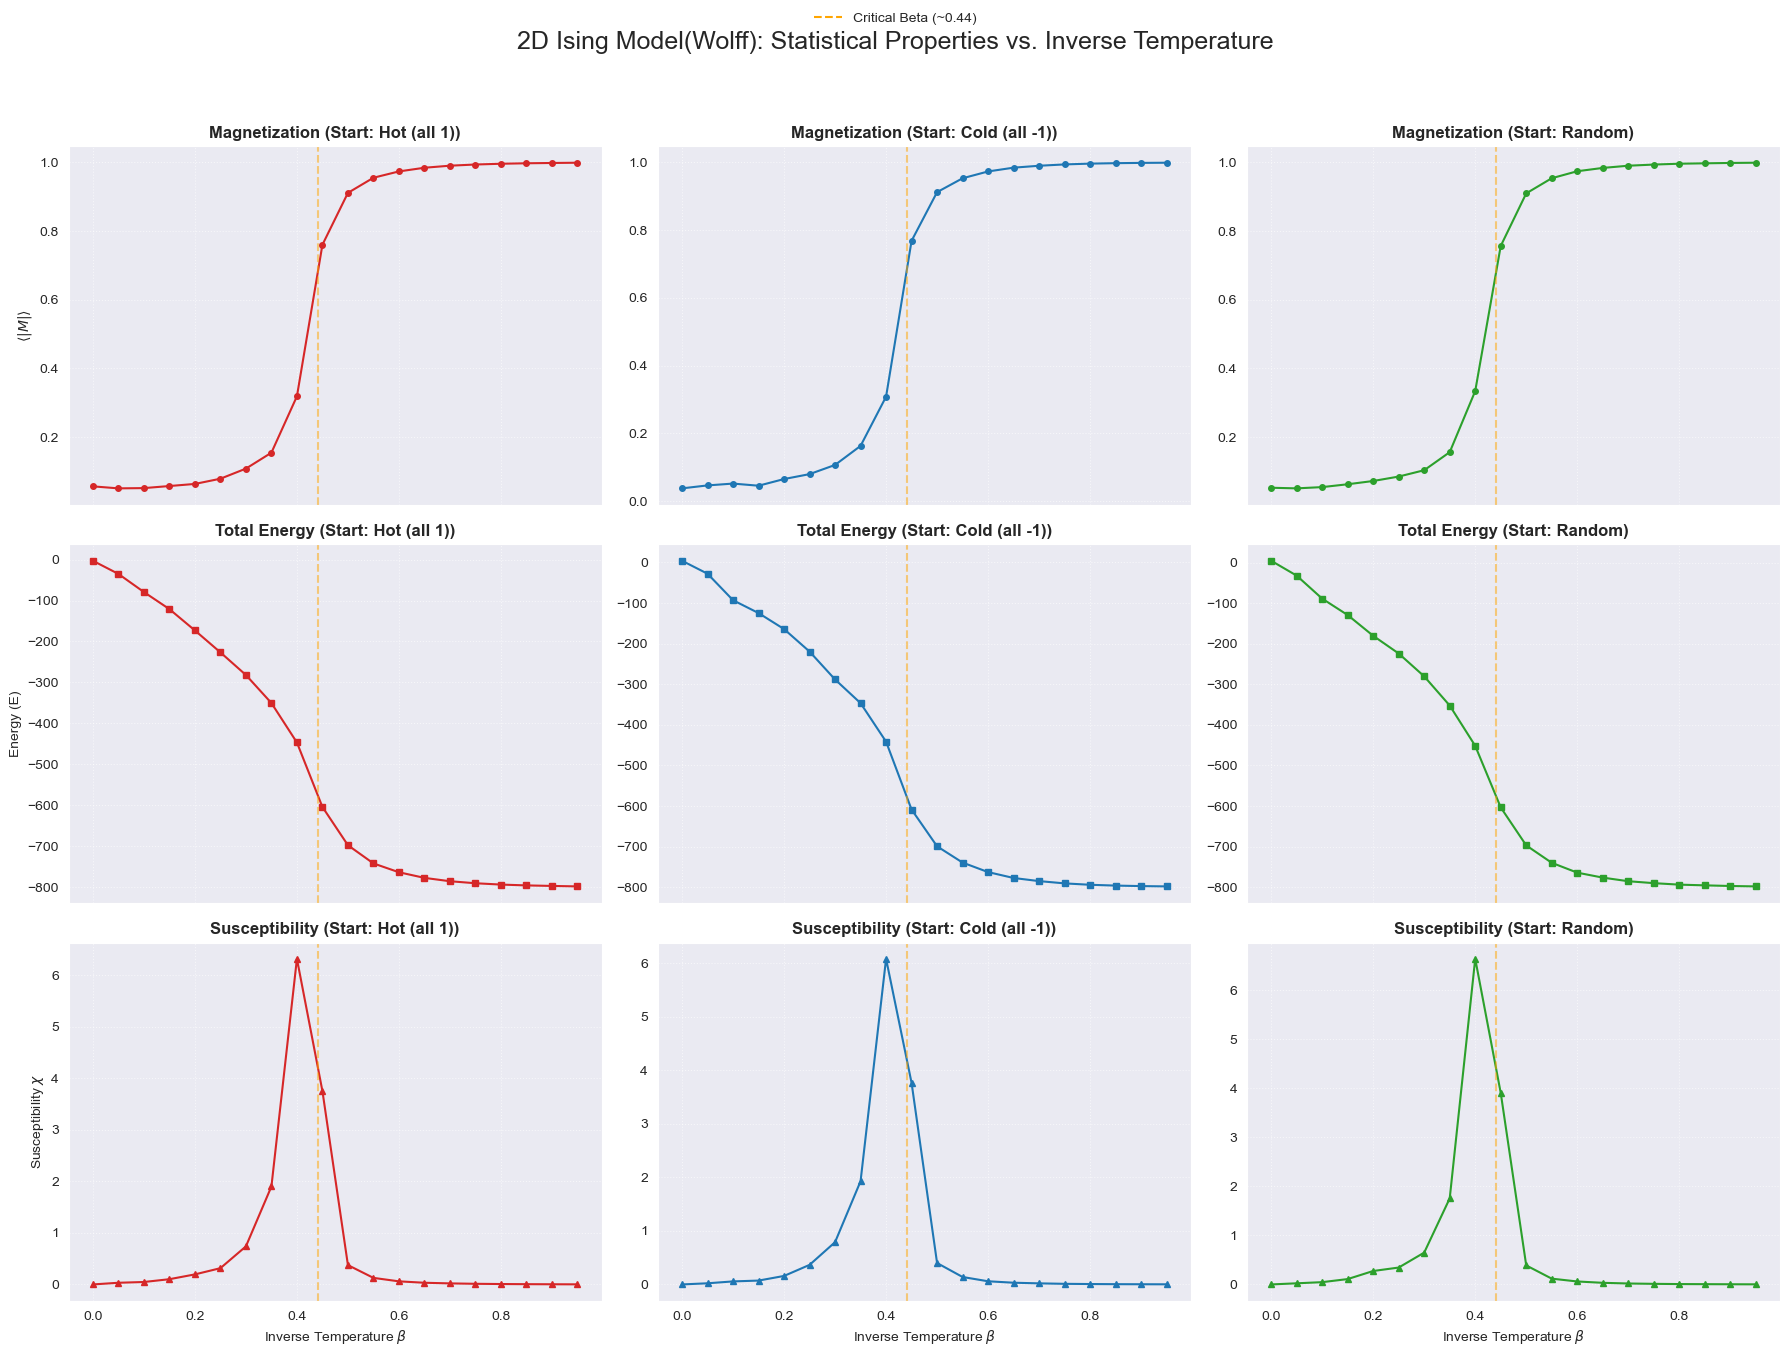

In [16]:
plot_stats(mag = mag_wolff, tot_en = tot_en_wolff, sus = sus_wolff, title_model="Wolff")